# **Trader Performance vs Market Sentiment Analysis**

## **1. Objective**
The objective of this analysis is to examine how Bitcoin market sentiment 
(Fear/Greed Index) influences trader behavior and profitability on Hyperliquid.

We analyze trading performance metrics such as average PnL, win rate, 
and trade frequency across different sentiment regimes to identify 
behavioral patterns and actionable strategy insights.

## **2. Data Preparation**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [2]:
sentiment.head()
trades.head()

sentiment.info()
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

## **3. Data Cleaning and Alignment**

In [4]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

trades['date'] = trades['Timestamp IST'].dt.date

In [5]:
trades[['Timestamp IST','date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [6]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [7]:
merged = trades.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


## **4. Feature Engineering**

In [10]:
merged['win'] = merged['Closed PnL'] > 0

## **5. Sentiment vs Performance Analysis**

In [11]:
win_sentiment = merged.groupby('classification')['win'].mean()

In [12]:
pnl_sentiment = merged.groupby('classification')['Closed PnL'].mean()

### 5.1 Average Trade Profitability by Market Sentiment

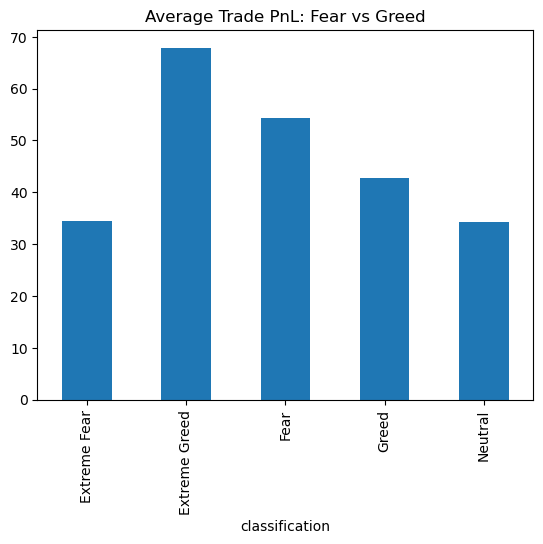

In [13]:
pnl_sentiment.plot(kind='bar')
plt.title("Average Trade PnL: Fear vs Greed")
plt.show()

### 5.2 Win Rate Across Sentiment Regimes

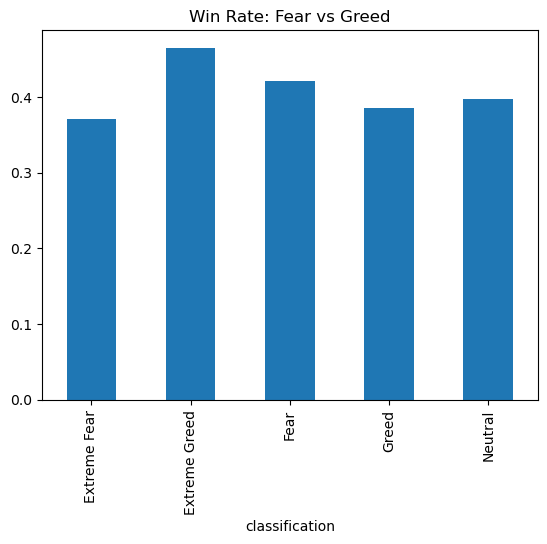

In [14]:
win_sentiment.plot(kind='bar')
plt.title("Win Rate: Fear vs Greed")
plt.show()

### 5.3 Trade Participation by Sentiment

In [18]:
trade_count = merged.groupby('classification').size()

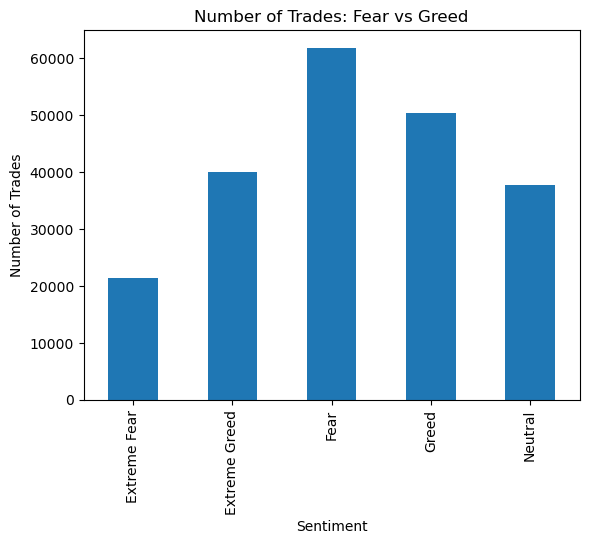

In [19]:
trade_count.plot(kind='bar')
plt.title("Number of Trades: Fear vs Greed")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.show()

## **6. Trader Segmentation Analysis**

In [21]:
trade_counts = merged['Account'].value_counts()
top_30 = trade_counts.nlargest(int(len(trade_counts)*0.3)).index

merged['freq_segment'] = np.where(
    merged['Account'].isin(top_30),
    'Frequent',
    'Infrequent'
)

In [22]:
merged.groupby(['freq_segment','classification'])['Closed PnL'].mean()

freq_segment  classification
Frequent      Extreme Fear       17.227902
              Extreme Greed      67.924011
              Fear               29.262219
              Greed              30.718584
              Neutral            30.506754
Infrequent    Extreme Fear       59.973476
              Extreme Greed      67.792298
              Fear              107.712523
              Greed              73.934442
              Neutral            46.975268
Name: Closed PnL, dtype: float64

Frequent traders exhibit significantly lower profitability during Extreme Fear
(17.2) compared to Infrequent traders (60.0), indicating higher vulnerability
to adverse market sentiment.

However, both segments benefit during Extreme Greed periods (67.9), suggesting
that strong bullish momentum lifts overall performance regardless of trading frequency.

This implies that high trading activity may amplify downside risk during negative sentiment regimes.

## **7. Key Insights**

### Insight 1: Extreme Greed Drives Peak Profitability

Extreme Greed periods demonstrate the highest average trade PnL (67.9)
and the highest win rate (46.5%). This suggests that strong bullish
momentum significantly enhances trader performance.

---

### Insight 2: Extreme Fear Significantly Reduces Success Rates

Extreme Fear periods show the lowest average profitability (34.5)
and lowest win rate (37%), indicating that heightened uncertainty
negatively impacts trade outcomes.

---

### Insight 3: Moderate Fear Outperforms Moderate Greed

Interestingly, standard Fear days exhibit higher win rates (42%)
compared to Greed days (38%). This suggests that traders may behave
more cautiously and manage risk more effectively during moderate fear
than during mild optimism.

---

### Insight 4: Trading Frequency Amplifies Downside Risk

Frequent traders show significantly lower profitability during Extreme
Fear compared to Infrequent traders, indicating that high trading
activity may amplify exposure to adverse market sentiment.

## **8. Strategy Recommendations**

1. Reduce Position Size During Extreme Fear  
   During periods of Extreme Fear, traders—especially high-frequency
   participants—should reduce position sizes and risk exposure to
   mitigate lower win probabilities and higher volatility.

2. Capitalize on Strong Bullish Momentum  
   During Extreme Greed periods, increasing trade participation may be
   advantageous, as both profitability and win rates peak during these phases.

3. Maintain Discipline During Moderate Greed  
   Since win rates decline during standard Greed periods, traders should
   avoid overconfidence and maintain disciplined risk management.